# H-DNA Detection Benchmark

Inject experimental sequences (forming & non-forming) into E. coli K-12, run HSeeker and the R `triplex` package, evaluate with confusion matrix and ROC curves. A second pass uses the HDNA stability score to check whether specificity improves.

In [ ]:
import json
import random
import sys
from pathlib import Path
from subprocess import run

OUTPUT_DIR = Path("benchmark_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, RocCurveDisplay
)
from sklearn.utils import resample
from tqdm import tqdm

import sys
from _scoring import score_hit

def score_seq(seq, arm_length):
    """Score a full H-DNA sequence given its arm length.
    Returns a dict with total_score, putative_triplex, etc., or None on failure.
    """
    seq = seq.upper()
    if arm_length <= 0 or 2 * arm_length > len(seq):
        return None
    left   = seq[:arm_length]
    spacer = seq[arm_length:-arm_length]
    right  = seq[-arm_length:]
    return score_hit(left, spacer, right, arm_length)

## 1. Load experimental sequences

In [2]:
seq_df = pd.read_csv("hdna_experimental_sequences_final.csv")

# normalise label: forming / non_forming
seq_df["label"] = seq_df["label"].str.strip().str.replace("-", "_")
assert set(seq_df["label"].unique()).issubset({"forming", "non_forming"}), \
    f"Unexpected labels: {seq_df['label'].unique()}"

print(seq_df[["record_id", "sequence_name", "label", "sequence_5to3"]].to_string())

   record_id                                   sequence_name        label                                               sequence_5to3
0   HDNA0001                                           pAA32      forming                            AAGGGAGAAAGGGGTATAGGGGAAAGAGGGAA
1   HDNA0002                                           pGG32      forming                            AAGGGAGAAGGGGGTATAGGGGGAAGAGGGAA
2   HDNA0003                                           pAG32      forming                            AAGGGAGAAAGGGGTATAGGGGGAAGAGGGAA
3   HDNA0004                                           pTG32      forming                            AAGGGAGAATGGGGTATAGGGGGAAGAGGGAA
4   HDNA0005                                           pAC32      forming                            AAGGGAGAAAGGGGTATAGGGGCAAGAGGGAA
5   HDNA0006                                           pGT32      forming                            AAGGGAGAAGGGGGTATAGGGGTAAGAGGGAA
6   HDNA0007                                           pGC32  

In [3]:
## Load additional motifs and merge with experimental sequences
add_df = pd.read_csv("hseeker_additional_motifs.csv")

add_df = add_df.rename(columns={
    "seq_id":         "record_id",
    "full_dna_motif": "sequence_5to3",
    "authors":        "first_author",
})[["record_id", "sequence_5to3", "first_author", "year", "is_hdna_forming"]]

add_df["sequence_name"] = add_df["record_id"]
add_df["label"] = add_df["is_hdna_forming"].map({True: "forming", False: "non_forming"})
add_df = add_df.drop(columns=["is_hdna_forming"])

# remove entries already present in seq_df by record_id OR exact sequence
existing_seqs = seq_df["sequence_5to3"].str.upper().tolist()
add_df = add_df[
    ~add_df["record_id"].isin(seq_df["record_id"]) &
    ~add_df["sequence_5to3"].str.upper().isin(existing_seqs)
]
# also drop internal sequence duplicates within add_df (keep first occurrence)
add_df = add_df.drop_duplicates(subset=["sequence_5to3"], keep="first")

seq_df = pd.concat([seq_df, add_df], ignore_index=True)

print(f"Combined: {len(seq_df)} sequences  "
      f"({(seq_df.label=='forming').sum()} forming, "
      f"{(seq_df.label=='non_forming').sum()} non-forming)")
print(f"  — experimental: {len(seq_df[~seq_df['record_id'].isin(add_df['record_id'])])}")
print(f"  — additional motifs: {len(add_df)}")


Combined: 79 sequences  (70 forming, 9 non-forming)
  — experimental: 54
  — additional motifs: 25


## 2. Write FASTA with labels

In [ ]:
SEED_FASTA = str(OUTPUT_DIR / "hdna_experimental_sequences.fasta")

with open(SEED_FASTA, "w") as f:
    for _, row in seq_df.iterrows():
        f.write(f">{row['record_id']}, {row['sequence_name']}, {row['first_author']}, {row['year']}, {row['label']}\n")
        f.write(f"{row['sequence_5to3']}\n")

print(f"Wrote {len(seq_df)} sequences to {SEED_FASTA}")

Wrote 79 sequences to hdna_experimental_sequences.fasta


## 2b. PIT elements FASTA
All 25 E. coli PIT elements (Escude et al. 1999) — all experimentally confirmed forming.

In [ ]:
pit_elements = [
    ("AGGGAGAGGG", "ccg",   "GGGTGAGGGT"),   # 1
    ("GGGGAGAGGG", "tta",   "GGGTGAGGGG"),   # 2
    ("GGGAGAGGG",  "ccg",   "GGGTGAGGG"),    # 3
    ("AGGGAGAGGG", "tta",   "GGGTGAGGGT"),   # 4
    ("AGGGAGAG",   "g",     "GTTAGGGT"),     # 5
    ("GGGGAGAGGG", "ccg",   "GGGTGAGGGG"),   # 6
    ("AGGGAGAGG",  "gtcgg", "GGTGAGGGT"),    # 7
    ("GGGGAGAGGG", "tta",   "GGGTGAGGGG"),   # 8
    ("GGGGAGAGGG", "tta",   "GGGTGAGGGG"),   # 9
    ("AGGGTGAGGG", "ctg",   "GGGTGAGGGT"),   # 10
    ("GGGGAGAGGG", "tta",   "GGGTGAGGGG"),   # 11
    ("GGGGAGAGG",  "attag", "GGTGAGGGG"),    # 12
    ("GGGGAGAGGG", "tta",   "GGGTGAGGGG"),   # 13
    ("GGAGAGGG",   "ttt",   "GGGTGAGGGA"),   # 14
    ("GGGGAGAGGG", "tta",   "GGGTGAGGGG"),   # 15
    ("GGGGAGAGGG", "tta",   "GGGTGAGGGG"),   # 16
    ("GGGGAGAGGG", "tta",   "GGGAGAGGGG"),   # 17
    ("GGGAGAGGG",  "ccg",   "GGGTGAGGG"),    # 18
    ("GGGGTGAGGG", "tta",   "GGGTGAGGGG"),   # 19
    ("GGGGAGAGGG", "tta",   "GGGTGAGGGG"),   # 20
    ("GGGGAGAGGG", "tta",   "GGGTGAGGGG"),   # 21
    ("GGGGAGAGGG", "tta",   "GGGTGAGGGG"),   # 22
    ("GGGGAGAGGG", "tta",   "GGGTGAGAGG"),   # 23
    ("GGGGAGAGGG", "tta",   "GGGTGAGGGG"),   # 24
    ("GGGGAGAGGG", "ccg",   "GGGTGAGGGG"),   # 25
]

PIT_FASTA = str(OUTPUT_DIR / "pit_elements.fasta")

pit_rows = []
with open(PIT_FASTA, "w") as f:
    for idx, (la, sp, ra) in enumerate(pit_elements, 1):
        rid  = f"PIT{idx:02d}"
        seq  = (la + sp + ra).upper()
        f.write(f">{rid}, Escude et al., 1999, forming\n")
        f.write(f"{seq}\n")
        pit_rows.append({"record_id": rid, "sequence_name": rid,
                          "sequence_5to3": seq, "arm_length": len(la),
                          "label": "forming"})

pit_df = pd.DataFrame(pit_rows)
print(f"Wrote {len(pit_df)} PIT elements to {PIT_FASTA}")
print(pit_df[["record_id", "sequence_5to3", "arm_length"]].to_string())


Wrote 25 PIT elements to pit_elements.fasta
   record_id            sequence_5to3  arm_length
0      PIT01  AGGGAGAGGGCCGGGGTGAGGGT          10
1      PIT02  GGGGAGAGGGTTAGGGTGAGGGG          10
2      PIT03    GGGAGAGGGCCGGGGTGAGGG           9
3      PIT04  AGGGAGAGGGTTAGGGTGAGGGT          10
4      PIT05        AGGGAGAGGGTTAGGGT           8
5      PIT06  GGGGAGAGGGCCGGGGTGAGGGG          10
6      PIT07  AGGGAGAGGGTCGGGGTGAGGGT           9
7      PIT08  GGGGAGAGGGTTAGGGTGAGGGG          10
8      PIT09  GGGGAGAGGGTTAGGGTGAGGGG          10
9      PIT10  AGGGTGAGGGCTGGGGTGAGGGT          10
10     PIT11  GGGGAGAGGGTTAGGGTGAGGGG          10
11     PIT12  GGGGAGAGGATTAGGGTGAGGGG           9
12     PIT13  GGGGAGAGGGTTAGGGTGAGGGG          10
13     PIT14    GGAGAGGGTTTGGGTGAGGGA           8
14     PIT15  GGGGAGAGGGTTAGGGTGAGGGG          10
15     PIT16  GGGGAGAGGGTTAGGGTGAGGGG          10
16     PIT17  GGGGAGAGGGTTAGGGAGAGGGG          10
17     PIT18    GGGAGAGGGCCGGGGTGAGGG           9
18    

## 3. Inject each sequence 5× into E. coli K-12

In [ ]:
GENOME_FNA  = "k12.fna"
OUT_FNA     = str(OUTPUT_DIR / "hdna_benchmark_injected.fna")
OUT_JSON    = str(OUTPUT_DIR / "hdna_benchmark_insertions.json")
N_REPLICATES = 1
MARGIN       = 500
SEED         = 42

def read_single_fasta(fin):
    header, parts = None, []
    with open(fin) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                header = line[1:]
            else:
                parts.append(line)
    return header, "".join(parts)


def inject_sequences(seq_df, genome_fna=GENOME_FNA,
                     out_fna=OUT_FNA, out_json=OUT_JSON,
                     n_replicates=N_REPLICATES,
                     margin=MARGIN, seed=SEED):
    genome_header, genome = read_single_fasta(genome_fna)
    rng = random.Random(seed)

    planned = []
    used_positions = set()
    for rep in range(1, n_replicates + 1):
        for _, row in seq_df.iterrows():
            seq = row["sequence_5to3"].upper()
            for _ in range(1000):
                pos = rng.randint(margin, len(genome) - margin - len(seq))
                if not any(abs(pos - p) < 200 for p in used_positions):
                    break
            used_positions.add(pos)
            uid = f"{row['record_id']}_rep{rep}"
            planned.append((uid, row["record_id"], row["sequence_name"],
                            seq, row["label"], pos))

    planned_sorted_desc = sorted(planned, key=lambda x: x[5], reverse=True)
    for uid, rid, name, seq, label, pos in planned_sorted_desc:
        genome = genome[:pos] + seq + genome[pos:]

    insertions = []
    offset = 0
    for uid, rid, name, seq, label, orig_pos in sorted(planned, key=lambda x: x[5]):
        final_pos = orig_pos + offset
        insertions.append({
            "uid": uid,
            "record_id": rid,
            "sequence_name": name,
            "label": label,
            "sequence": seq,
            "position": final_pos,
            "original_position": orig_pos,
        })
        offset += len(seq)

    with open(out_fna, "w") as f:
        f.write(f">{genome_header}\n")
        for i in range(0, len(genome), 80):
            f.write(genome[i:i+80] + "\n")

    with open(out_json, "w") as f:
        json.dump(insertions, f, indent=2)

    print(f"Injected {len(insertions)} sequences ({n_replicates}× each) into {out_fna}")
    return out_fna, insertions


seeded_fna, insertions = inject_sequences(seq_df)
print(f'Total unique sequences: {len(seq_df)} ({(seq_df.label=="forming").sum()} forming, {(seq_df.label=="non_forming").sum()} non-forming)')

Injected 79 sequences (1× each) into hdna_benchmark_injected.fna
Total unique sequences: 79 (70 forming, 9 non-forming)


## 4. Run HSeeker

In [ ]:
HSEEKER_OUT = str(OUTPUT_DIR / "hdna_benchmark")
HSEEKER_TSV = f"{HSEEKER_OUT}_HDNA.tsv"

cmd = (
    f"hseeker -seq {seeded_fna} "
    f"-minrep 8 -maxspacer 10 -mismatch 0.15 -maxrep 1000 -purity 0.9 "
    f"-out {HSEEKER_OUT}"
)
print("Running:", cmd)
result = run(cmd, shell=True, capture_output=True, text=True)
print(result.stdout[-2000:] if result.stdout else "(no stdout)")
if result.returncode != 0:
    print("STDERR:", result.stderr[-1000:])


Running: hseeker -seq hdna_benchmark_injected.fna -minrep 8 -maxspacer 10 -mismatch 0.15 -maxrep 1000 -purity 0.9 -out hdna_benchmark


(no stdout)


In [ ]:
df_hits = pd.read_table(HSEEKER_TSV)
print(f"{len(df_hits)} HSeeker hits")
df_hits.head()

362 HSeeker hits


,seq_id,source,start,end,arm_length,spacer_length,total_length,ga_pct,ct_pct,mirror_identity,is_perfect,left_arm,spacer,right_arm,full_sequence,stacking_score,pairing_score,total_score,putative_triplex
0,NC_000913.3,findHDNA,5093,5112,8,4,20,100.0,0.0,87.5,False,gaaaaatg,acag,ggaaaaag,gaaaaatgacagggaaaaag,15.0,28.635,43.635,GAAAAATG[ACAG]GGAAAAAG
1,NC_000913.3,findHDNA,32922,32938,8,1,17,100.0,0.0,87.5,False,agagaagg,c,gaaagaga,agagaaggcgaaagaga,15.0,32.405,47.405,AGAGAAGG[C]GAAAGAGA
2,NC_000913.3,findHDNA,55029,55051,8,7,23,100.0,0.0,100.0,True,gggagggg,cgcttat,ggggaggg,gggaggggcgcttatggggaggg,35.0,57.030,92.030,GGGAGGGG[CGCTTAT]GGGGAGGG
3,NC_000913.3,findHDNA,74356,74378,8,7,23,100.0,0.0,87.5,False,acagagag,cagtgcc,gagagaaa,acagagagcagtgccgagagaaa,15.0,32.405,47.405,ACAGAGAG[CAGTGCC]GAGAGAAA
4,NC_000913.3,findHDNA,97891,97916,10,6,26,90.0,10.0,90.0,False,cgagaaagtg,ctgaat,gtgaaagaga,cgagaaagtgctgaatgtgaaagaga,20.0,40.005,60.005,GAGAAAGTG[CTGAAT]GTGAAAGAG


## 5. Match hits to insertions

In [ ]:
OVERLAP_THRESHOLD = 0.8

def hits_overlap_insertion(ins, detected, threshold=OVERLAP_THRESHOLD):
    s = ins["position"]
    e = s + len(ins["sequence"]) - 1
    ins_len = e - s
    best = None
    for h in detected:
        ov = min(h["end"], e) - max(h["start"], s)
        hl = h["end"] - h["start"]
        if ov > 0:
            frac_hit = ov / hl if hl > 0 else 0
            frac_ins = ov / ins_len if ins_len > 0 else 0
            if max(frac_hit, frac_ins) >= threshold:
                if best is None or ov > best["overlap"]:
                    best = {**h, "overlap": ov}
    return best


detected = [
    {"start": int(r["start"]), "end": int(r["end"]),
     "full_sequence": r["full_sequence"], "arm_length": int(r["arm_length"])}
    for _, r in df_hits.iterrows()
]

records = []
for ins in tqdm(insertions, desc="Matching"):
    hit = hits_overlap_insertion(ins, detected)
    is_forming = ins["label"] == "forming"
    hseeker_pos = hit is not None

    stab_score = np.nan
    if hit is not None:
        res = score_seq(hit["full_sequence"], hit["arm_length"])
        if res is not None:
            stab_score = res["total_score"]

    records.append({
        "uid":           ins["uid"],
        "record_id":     ins["record_id"],
        "sequence_name": ins["sequence_name"],
        "label":         ins["label"],
        "is_forming":    is_forming,
        "hseeker_hit":   hseeker_pos,
        "stab_score":    stab_score,
    })

results_df = pd.DataFrame(records)
results_df.head(10)

Matching: 100%|██████████| 79/79 [00:00<00:00, 8638.13it/s]


,uid,record_id,sequence_name,label,is_forming,hseeker_hit,stab_score
0,HDNA0024_rep1,HDNA0024,R2-3′ (H-DNA buffer),forming,True,True,92.030
1,HDNA0002_rep1,HDNA0002,pGG32,forming,True,True,143.720
2,HDNA0017_rep1,HDNA0017,Con-2,forming,True,True,136.180
3,HDNA0012_rep1,HDNA0012,pTT32,forming,True,True,119.235
4,HDNA0011_rep1,HDNA0011,pTA32,forming,True,True,119.235
5,TTCCC20_avian_rep1,TTCCC20_avian,TTCCC20_avian,forming,True,True,494.140
6,HDNA0039_rep1,HDNA0039,(dG)n-(dC)n_Lyamichev-Mirkin-Frank-Kamenetskii,forming,True,True,158.800
7,HDNA0050_rep1,HDNA0050,pRW1411,forming,True,True,109.690
8,SV40_GACT22_rep1,SV40_GACT22,SV40_GACT22,forming,True,True,209.300
9,HDNA0049_rep1,HDNA0049,pRW1404,forming,True,True,145.010


## 6. Evaluation — Confusion Matrices, MCC & ROC

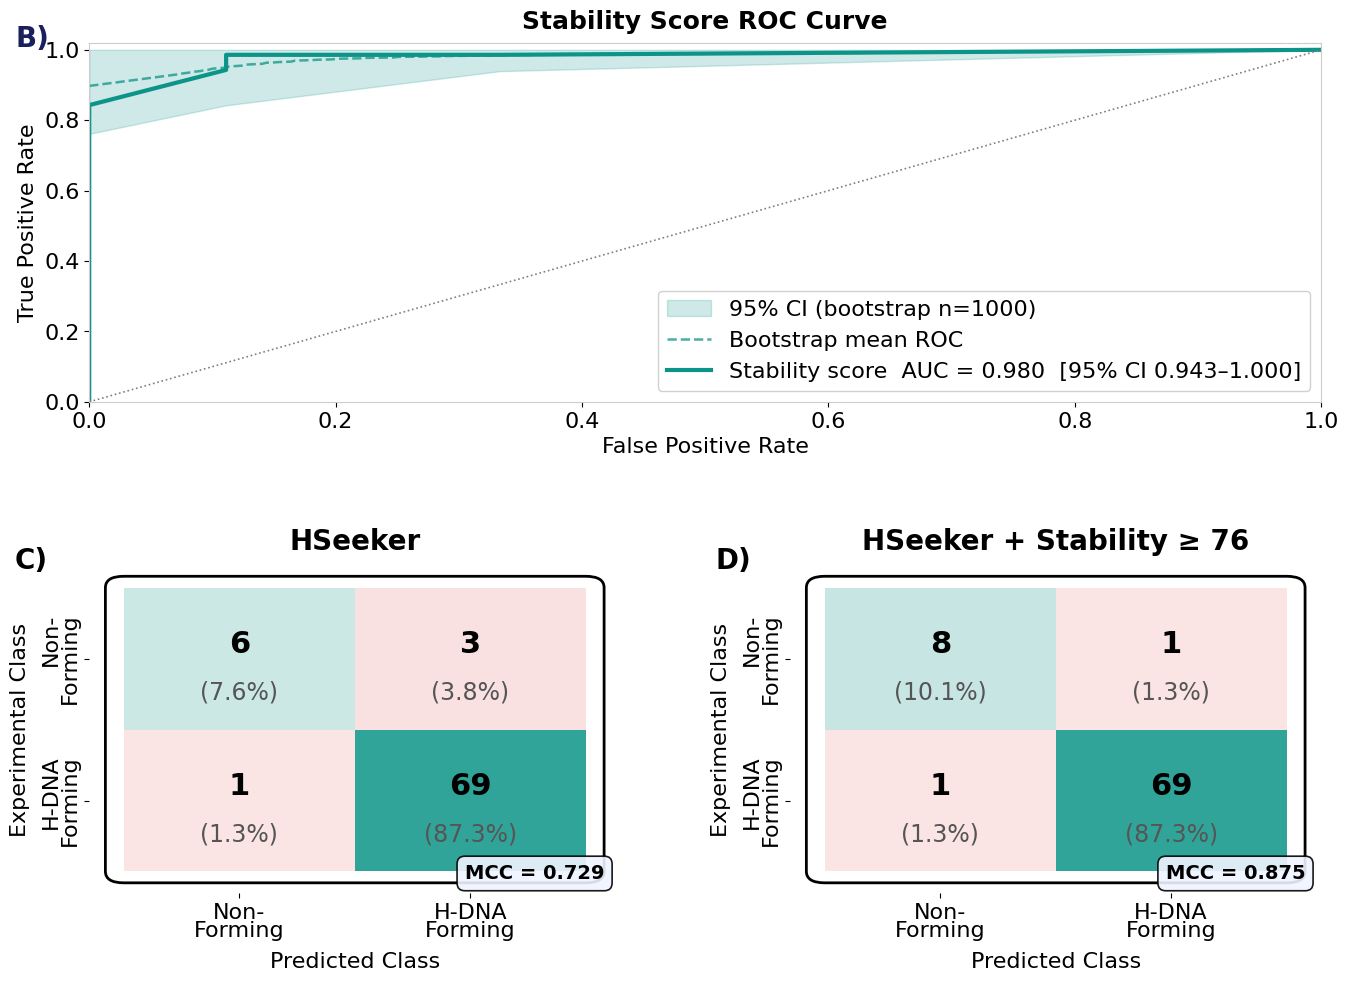

Saved hdna_benchmark_figure.png


In [ ]:
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, matthews_corrcoef
)
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

# ── scores & predictions ──────────────────────────────────────────────────
y_true          = results_df["is_forming"].astype(int).values
y_score_hseeker = results_df["hseeker_hit"].astype(float).values
y_score_stab    = results_df["stab_score"].fillna(0).values

fpr_s, tpr_s, thresholds_s = roc_curve(y_true, y_score_stab)
opt_thresh = thresholds_s[np.argmax(tpr_s - fpr_s)]

y_pred1 = y_score_hseeker.astype(int)
y_pred2 = (
    results_df["hseeker_hit"] & (results_df["stab_score"].fillna(0) >= opt_thresh)
).astype(int).values

cm1 = confusion_matrix(y_true, y_pred1)
cm2 = confusion_matrix(y_true, y_pred2)

def compute_metrics(y_true, y_pred):
    TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()
    sens = TP/(TP+FN) if TP+FN else 0
    spec = TN/(TN+FP) if TN+FP else 0
    prec = TP/(TP+FP) if TP+FP else 0
    f1   = 2*prec*sens/(prec+sens) if prec+sens else 0
    mcc  = matthews_corrcoef(y_true, y_pred)
    return dict(sens=sens, spec=spec, prec=prec, f1=f1, mcc=mcc)

m1 = compute_metrics(y_true, y_pred1)
m2 = compute_metrics(y_true, y_pred2)

# ── bootstrap ROC CI ──────────────────────────────────────────────────────
N_BOOT = 1000
rng_b  = np.random.default_rng(42)
n      = len(y_true)

def bootstrap_roc(y_true, y_score):
    fpr_full, tpr_full, _ = roc_curve(y_true, y_score)
    grid = np.linspace(0, 1, 300)
    grid_tprs, anchor_tprs, aucs = [], {f: [] for f in fpr_full}, []
    for _ in range(N_BOOT):
        idx = rng_b.integers(0, n, size=n)
        yt, ys = y_true[idx], y_score[idx]
        if len(np.unique(yt)) < 2: continue
        fp, tp, _ = roc_curve(yt, ys)
        grid_tprs.append(np.interp(grid, fp, tp))
        for f in fpr_full:
            anchor_tprs[f].append(float(np.interp(f, fp, tp)))
        aucs.append(auc(fp, tp))
    mean_tpr = np.array(grid_tprs).mean(0)
    lo  = np.array([np.percentile(anchor_tprs[f], 2.5)  for f in fpr_full])
    hi  = np.array([np.percentile(anchor_tprs[f], 97.5) for f in fpr_full])
    return (fpr_full, tpr_full, mean_tpr, grid, lo, hi,
            auc(fpr_full, tpr_full), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5))

fpr_s, tpr_s, mean_s, grid, lo_s, hi_s, auc_s, l_auc, u_auc = bootstrap_roc(y_true, y_score_stab)

# ── palette ───────────────────────────────────────────────────────────────
NAVY  = "#1a1f5e"
TEAL  = "#0d9488"
CORAL = "#e05a5a"
WHITE = "#ffffff"
LABELS = ["Non-\nForming", "H-DNA\nForming"]

# ── figure layout ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10), facecolor=WHITE)
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        height_ratios=[1.1, 1],
                        hspace=0.48, wspace=0.32,
                        left=0.08, right=0.96, top=0.93, bottom=0.08)
ax_roc = fig.add_subplot(gs[0, :])
ax_cm1 = fig.add_subplot(gs[1, 0])
ax_cm2 = fig.add_subplot(gs[1, 1])

# ── A) ROC panel ──────────────────────────────────────────────────────────
ax_roc.set_facecolor(WHITE)
ax_roc.fill_between(fpr_s, lo_s, hi_s, alpha=0.20, color=TEAL, label="95% CI (bootstrap n=1000)")
ax_roc.plot(grid, mean_s, lw=1.8, ls="--", color=TEAL, alpha=0.75, label="Bootstrap mean ROC")
ax_roc.plot(fpr_s, tpr_s, lw=3, color=TEAL,
            label=f"Stability score  AUC = {auc_s:.3f}  [95% CI {l_auc:.3f}\u2013{u_auc:.3f}]")
ax_roc.plot([0,1],[0,1], color="grey", lw=1.2, ls=":")
ax_roc.set_xlabel("False Positive Rate", fontsize=16)
ax_roc.set_ylabel("True Positive Rate", fontsize=16)
ax_roc.set_title("Stability Score ROC Curve",
                 fontsize=18, fontweight="bold", pad=10)
ax_roc.legend(loc="lower right", fontsize=16, framealpha=0.9)
ax_roc.tick_params(axis="both", which="major", labelsize=16)
ax_roc.set_xlim(0,1); ax_roc.set_ylim(0,1.02)
for sp in ax_roc.spines.values(): sp.set_color("#cccccc")
ax_roc.text(-0.06, 1.05, "B)", transform=ax_roc.transAxes,
            fontsize=20, fontweight="bold", va="top", color=NAVY)

# ── confusion matrix helper ───────────────────────────────────────────────
def draw_cm(ax, cm, title, mcc, panel_label):
    ax.set_facecolor(WHITE)
    vmax = cm.max()
    for i in range(2):
        for j in range(2):
            val   = cm[i, j]
            color = TEAL if i == j else CORAL
            alpha = 0.15 + 0.70 * (val / vmax)
            ax.add_patch(plt.Rectangle([j-0.5, i-0.5], 1, 1,
                         facecolor=color, alpha=alpha, zorder=1))
            ax.text(j, i-0.10, str(val),
                    ha="center", va="center", fontsize=22, fontweight="bold",
                    color="black", zorder=2)
            ax.text(j, i+0.24, f"({100*val/cm.sum():.1f}%)",
                    ha="center", va="center", fontsize=17, color="#555555", zorder=2)
    # border rectangle with padding
    border = mpatches.FancyBboxPatch(
        (-0.5, -0.5), 2, 2,
        boxstyle="round,pad=0.08",
        linewidth=2, edgecolor="black", facecolor="none", zorder=3
    )
    ax.add_patch(border)
    ax.set_xlim(-0.65, 1.65); ax.set_ylim(-0.65, 1.65)
    ax.set_xticks([0,1]); ax.set_xticklabels(LABELS, fontsize=16, linespacing=0.9)
    ax.set_yticks([0,1]); ax.set_yticklabels(LABELS, fontsize=16, rotation=90, va="center", linespacing=0.9)
    ax.set_xlabel("Predicted Class", fontsize=16, labelpad=8)
    ax.set_ylabel("Experimental Class", fontsize=16, labelpad=8)
    ax.set_title(title, fontsize=20, fontweight="bold", pad=12)
    ax.invert_yaxis()
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.text(0.97, 0.03,
            f"MCC = {mcc:.3f}",
            transform=ax.transAxes, 
            ha="right", 
            va="bottom", 
            fontsize=14,
            color="black", 
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.4", 
                      facecolor="#f0f4ff",
                      edgecolor="black", alpha=0.9, linewidth=1.2))
    ax.text(-0.14, 1.06, panel_label + ")", transform=ax.transAxes,
            fontsize=20, fontweight="bold", va="top", color="black")

draw_cm(ax_cm1, cm1, "HSeeker", m1["mcc"], "C")
draw_cm(ax_cm2, cm2, f"HSeeker + Stability \u2265 {opt_thresh:.0f}", m2["mcc"], "D")

plt.savefig(OUTPUT_DIR / "hdna_benchmark_figure.pdf", transparent=True, dpi=680, bbox_inches="tight", facecolor=WHITE)
plt.show()
print("Saved hdna_benchmark_figure.pdf")


## 7. Direct Sequences — HSeeker, R triplex, Triplexator

Run all three H-DNA detection tools directly on the experimental sequences and compare confusion matrices side-by-side.

In [ ]:
HSEEKER_DIRECT_FASTA = "hdna_direct_sequences.fasta"
HSEEKER_DIRECT_OUT   = "hdna_direct"
HSEEKER_DIRECT_TSV   = f"{HSEEKER_DIRECT_OUT}_HDNA.tsv"

# Write clean single-token headers so HSeeker seq_id == record_id
with open(HSEEKER_DIRECT_FASTA, "w") as f:
    for _, row in seq_df.iterrows():
        f.write(f">{row['record_id']}\n{row['sequence_5to3'].upper()}\n")

cmd = (
    f"hseeker -seq {HSEEKER_DIRECT_FASTA} "
    f"-minrep 8 -maxspacer 10 -mismatch 0.15 -maxrep 1000 -purity 0.9 "
    f"-out {HSEEKER_DIRECT_OUT}"
)
print("Running:", cmd)
result = run(cmd, shell=True, capture_output=True, text=True)
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])

df_direct_hits = pd.read_table(HSEEKER_DIRECT_TSV)
hseeker_direct_hit_ids = set(df_direct_hits["seq_id"].unique())
seq_df["hseeker_direct_hit"] = seq_df["record_id"].isin(hseeker_direct_hit_ids)
print(f"HSeeker direct: {seq_df['hseeker_direct_hit'].sum()}/{len(seq_df)} sequences detected")


Running: hseeker -seq hdna_direct_sequences.fasta -minrep 8 -maxspacer 10 -mismatch 0.15 -maxrep 1000 -purity 0.9 -out hdna_direct
HSeeker direct: 72/79 sequences detected


In [ ]:
TRIPLEX_LIB       = "/home1/10904/nikolchanchan/micromamba/envs/nonbdna/lib/R/library"  # nonbdna R library path
TRIPLEX_SCRIPT    = "run_triplex.R"
TRIPLEX_MIN_SCORE = 15
TRIPLEX_MIN_LEN   = 8    # match HSeeker minrep=8
TRIPLEX_MAX_LEN   = 50
TRIPLEX_SEQ_TYPE  = "prokaryotic"  # correct EVD params for E. coli

r_src = (
    'suppressPackageStartupMessages(library(triplex, lib.loc="' + TRIPLEX_LIB + '"))\n'
    'args       <- commandArgs(trailingOnly=TRUE)\n'
    'input_tsv  <- args[1]; output_tsv <- args[2]\n'
    'min_score  <- as.integer(args[3])\n'
    'min_len    <- as.integer(args[4]); max_len <- as.integer(args[5])\n'
    'seq_type   <- args[6]\n'
    'seqs <- read.table(input_tsv, sep="\\t", header=TRUE,\n'
    '                   stringsAsFactors=FALSE, quote="", comment.char="")\n'
    'rows <- list()\n'
    'for (i in seq_len(nrow(seqs))) {\n'
    '  rid <- as.character(seqs$record_id[i])\n'
    '  s   <- toupper(seqs$sequence[i])\n'
    '  dna <- tryCatch(DNAString(s), error=function(e) NULL)\n'
    '  hits <- if (!is.null(dna))\n'
    '    suppressMessages(\n'
    '      triplex.search(dna, min_score=min_score,\n'
    '                     min_len=min_len, max_len=max_len,\n'
    '                     seq_type=seq_type))\n'
    '  else NULL\n'
    '  if (!is.null(hits) && length(hits) > 0) {\n'
    '    m  <- mcols(hits)\n'
    '    df <- data.frame(\n'
    '      start     = start(hits),\n'
    '      width     = width(hits),\n'
    '      score     = m$score,\n'
    '      pvalue    = as.numeric(m$pvalue),\n'
    '      ins       = m$insdel,\n'
    '      type      = as.integer(m$type),\n'
    '      strand    = as.character(m$strand),\n'
    '      record_id = rid,\n'
    '      stringsAsFactors = FALSE\n'
    '    )\n'
    '  } else {\n'
    '    df <- data.frame(start=NA_integer_, width=NA_integer_, score=NA_real_,\n'
    '                     pvalue=NA_real_, ins=NA_integer_, type=NA_integer_,\n'
    '                     strand=NA_character_, record_id=rid,\n'
    '                     stringsAsFactors=FALSE)\n'
    '  }\n'
    '  rows[[length(rows)+1]] <- df\n'
    '  cat(sprintf("  [%d/%d] %s\\n", i, nrow(seqs), rid))\n'
    '}\n'
    'out <- do.call(rbind, rows)\n'
    'write.table(out, output_tsv, sep="\\t", row.names=FALSE, quote=FALSE, na="NA")\n'
    'cat("triplex done:", sum(!is.na(out$start)), "hits ->", output_tsv, "\\n")\n'
)

with open(TRIPLEX_SCRIPT, "w") as f:
    f.write(r_src)
print(f"Wrote {TRIPLEX_SCRIPT}")
print(f"Parameters: min_score={TRIPLEX_MIN_SCORE}, min_len={TRIPLEX_MIN_LEN}, "
      f"max_len={TRIPLEX_MAX_LEN}, seq_type={TRIPLEX_SEQ_TYPE}")


Wrote run_triplex.R
Parameters: min_score=15, min_len=8, max_len=50, seq_type=prokaryotic


In [ ]:
TRIPLEX_DIRECT_INPUT = "triplex_direct_input.tsv"
TRIPLEX_DIRECT_TSV   = "triplex_direct.tsv"

seq_df[["record_id", "sequence_5to3"]].rename(
    columns={"sequence_5to3": "sequence"}
).to_csv(TRIPLEX_DIRECT_INPUT, sep="\t", index=False)

print(f"Running triplex on {len(seq_df)} direct sequences (may be slow)...")
result = run(
    ["Rscript", TRIPLEX_SCRIPT,
     TRIPLEX_DIRECT_INPUT, TRIPLEX_DIRECT_TSV,
     str(TRIPLEX_MIN_SCORE), str(TRIPLEX_MIN_LEN), str(TRIPLEX_MAX_LEN),
     TRIPLEX_SEQ_TYPE],
    capture_output=True, text=True,
)
print(result.stdout.strip() or "(no stdout)")
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])

triplex_direct_df = pd.read_table(TRIPLEX_DIRECT_TSV, na_values=["NA"])
triplex_direct_hits = set(triplex_direct_df.dropna(subset=["start"])["record_id"].unique())
seq_df["triplex_direct_hit"] = seq_df["record_id"].isin(triplex_direct_hits)
print(f"Triplex detected {seq_df['triplex_direct_hit'].sum()}/{len(seq_df)} sequences directly")


Running triplex on 79 direct sequences (may be slow)...


Searching for triplex type 0...
Searching for triplex type 1...
Searching for triplex type 2...
Searching for triplex type 3...
Searching for triplex type 4...
Searching for triplex type 5...
Searching for triplex type 6...
Searching for triplex type 7...
  [1/79] HDNA0001
Searching for triplex type 0...
Searching for triplex type 1...
Searching for triplex type 2...
Searching for triplex type 3...
Searching for triplex type 4...
Searching for triplex type 5...
Searching for triplex type 6...
Searching for triplex type 7...
  [2/79] HDNA0002
Searching for triplex type 0...
Searching for triplex type 1...
Searching for triplex type 2...
Searching for triplex type 3...
Searching for triplex type 4...
Searching for triplex type 5...
Searching for triplex type 6...
Searching for triplex type 7...
  [3/79] HDNA0003
Searching for triplex type 0...
Searching for triplex type 1...
Searching for triplex type 2...
Searching for triplex type 3...
Searching for triplex type 4...
Searching for trip

In [ ]:
TRIPLEXATOR_BIN        = "/work/10904/nikolchanchan/vista/triplexator/bin/triplexator"
TRIPLEXATOR_MIN_LEN    = 10    # triplexator hard minimum is 10
TRIPLEXATOR_MAX_LEN    = -1    # unrestricted; sequences up to 198 bp
TRIPLEXATOR_ERROR      = 15    # % error rate — matches HSeeker mismatch=0.15
TRIPLEXATOR_DIRECT_OUT = "triplexator_direct_out"

cmd = [
    TRIPLEXATOR_BIN,
    "-ds", HSEEKER_DIRECT_FASTA,
    "-l", str(TRIPLEXATOR_MIN_LEN),
    "-L", str(TRIPLEXATOR_MAX_LEN),
    "-e", str(TRIPLEXATOR_ERROR),
    "-fr", "off",   # disable repeat filter — H-DNA motifs ARE purine/pyrimidine repeats
    "-o", TRIPLEXATOR_DIRECT_OUT,
]
print("Running:", " ".join(cmd))
result = run(cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])

tri_ttor_direct_raw = pd.read_table(
    TRIPLEXATOR_DIRECT_OUT,
    comment="#",
    header=None,
    names=["seq_id", "start", "end", "score", "strand",
           "error_rate", "errors", "g_rate", "dups", "tts", "dup_locs"],
    sep="\t",
)
triplexator_direct_hit_ids = set(tri_ttor_direct_raw["seq_id"].unique())
seq_df["triplexator_direct_hit"] = seq_df["record_id"].isin(triplexator_direct_hit_ids)
print(f"Triplexator detected {seq_df['triplexator_direct_hit'].sum()}/{len(seq_df)} sequences directly")

Running: /work/10904/nikolchanchan/vista/triplexator/bin/triplexator -ds hdna_direct_sequences.fasta -l 10 -L -1 -e 15 -fr off -o triplexator_direct_out
Triplexator detected 73/79 sequences directly


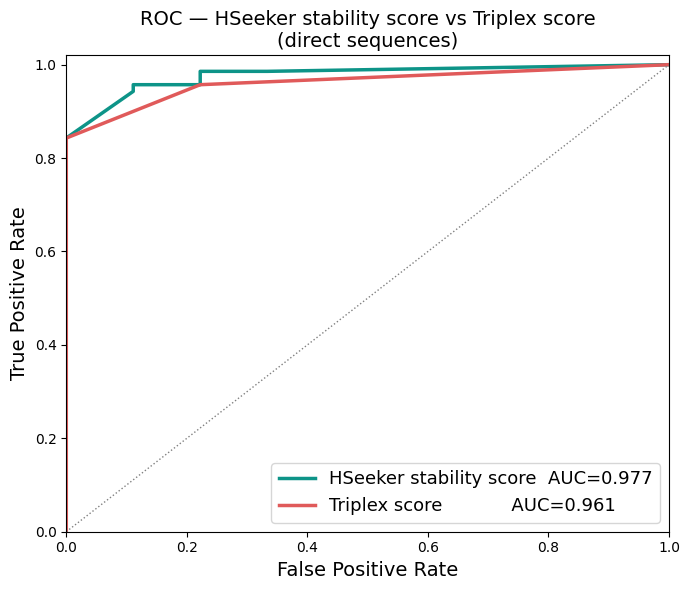

HSeeker AUC: 0.977   Triplex AUC: 0.961


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ── load data ─────────────────────────────────────────────────────────────
tri_dir = pd.read_table("triplex_direct.tsv", na_values=["NA"])

# max triplex score per sequence; 0 for sequences with no hit
tri_max = (tri_dir.groupby("record_id")["score"]
           .max()
           .reindex(seq_df["record_id"])
           .fillna(0)
           .values)

# HSeeker stability score (already computed)
hs_score = seq_df["record_id"].map(
    pd.read_table("hdna_direct_HDNA.tsv")
      .groupby("seq_id")["arm_length"].max()   # proxy: swap for stab_score if available
).fillna(0).values

# use stab scores from results_df if available — direct sequence version
# recompute via score_seq on direct hits
df_dir = pd.read_table("hdna_direct_HDNA.tsv")
stab_lookup = {}
for _, r in df_dir.iterrows():
    res = score_seq(r["full_sequence"], int(r["arm_length"]))
    if res:
        rid = r["seq_id"]
        if rid not in stab_lookup or res["total_score"] > stab_lookup[rid]:
            stab_lookup[rid] = res["total_score"]

hs_stab = seq_df["record_id"].map(stab_lookup).fillna(0).values
y_true  = seq_df["label"].eq("forming").astype(int).values

# ── ROC curves ────────────────────────────────────────────────────────────
fpr_hs,  tpr_hs,  _ = roc_curve(y_true, hs_stab)
fpr_tri, tpr_tri, _ = roc_curve(y_true, tri_max)
auc_hs  = auc(fpr_hs,  tpr_hs)
auc_tri = auc(fpr_tri, tpr_tri)

fig, ax = plt.subplots(figsize=(7, 6), facecolor=WHITE)
ax.plot(fpr_hs,  tpr_hs,  lw=2.5, color=TEAL,  label=f"HSeeker stability score  AUC={auc_hs:.3f}")
ax.plot(fpr_tri, tpr_tri, lw=2.5, color=CORAL, label=f"Triplex score            AUC={auc_tri:.3f}")
ax.plot([0,1],[0,1], color="grey", lw=1, ls=":")
ax.set_xlabel("False Positive Rate", fontsize=14)
ax.set_ylabel("True Positive Rate", fontsize=14)
ax.set_title("ROC — HSeeker stability score vs Triplex score\n(direct sequences)", fontsize=14)
ax.legend(fontsize=13, loc="lower right")
ax.set_xlim(0,1); ax.set_ylim(0,1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_hseeker_vs_triplex_direct.png", dpi=180, bbox_inches="tight", facecolor=WHITE)
plt.show()
print(f"HSeeker AUC: {auc_hs:.3f}   Triplex AUC: {auc_tri:.3f}")


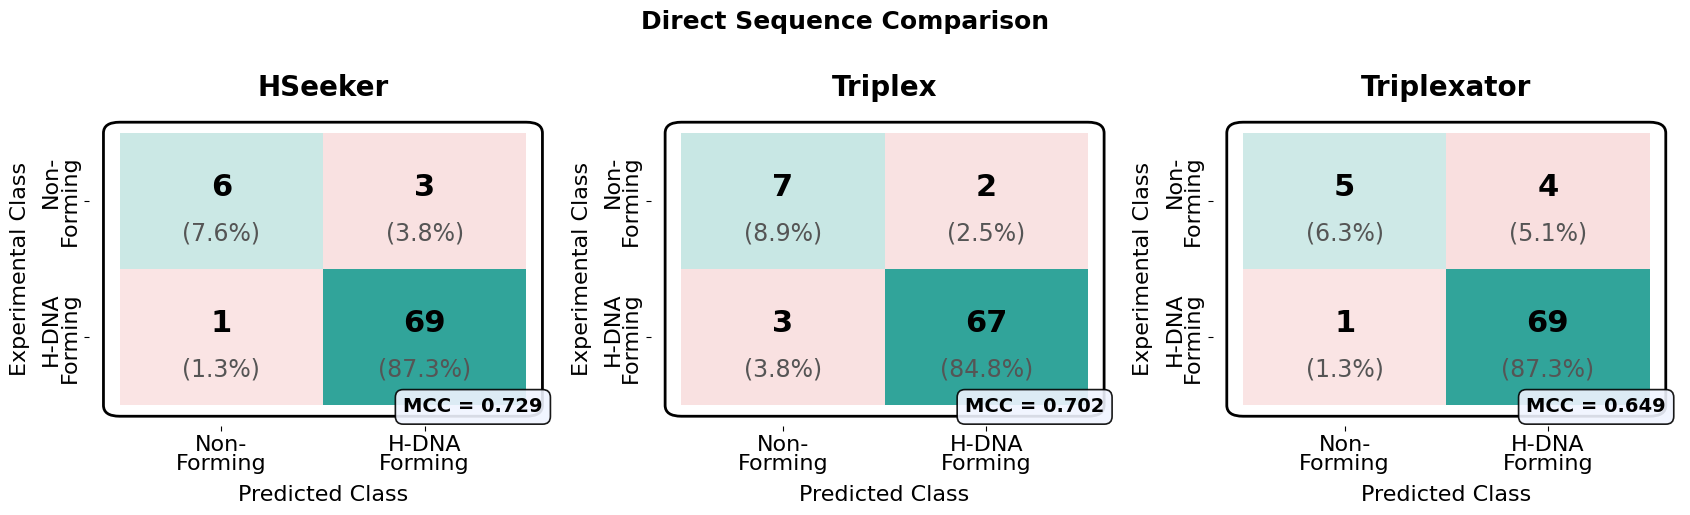

Direct — HSeeker MCC=0.729  R triplex MCC=0.702  Triplexator MCC=0.649


In [ ]:
from sklearn.metrics import confusion_matrix, matthews_corrcoef

y_true_dir   = seq_df["label"].eq("forming").astype(int).values
y_pred_hs    = seq_df["hseeker_direct_hit"].astype(int).values
y_pred_tri   = seq_df["triplex_direct_hit"].astype(int).values
y_pred_trtor_d = seq_df["triplexator_direct_hit"].astype(int).values

cm_hs_d     = confusion_matrix(y_true_dir, y_pred_hs)
cm_tri_d    = confusion_matrix(y_true_dir, y_pred_tri)
cm_trtor_d  = confusion_matrix(y_true_dir, y_pred_trtor_d)
mcc_hs_d    = matthews_corrcoef(y_true_dir, y_pred_hs)
mcc_tri_d   = matthews_corrcoef(y_true_dir, y_pred_tri)
mcc_trtor_d = matthews_corrcoef(y_true_dir, y_pred_trtor_d)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), facecolor=WHITE)
fig.suptitle("Direct Sequence Comparison",
             fontsize=18, fontweight="bold", color="black", y=1.02)

def draw_cm(ax, cm, title, mcc, panel_label):
    ax.set_facecolor(WHITE)
    vmax = cm.max()
    for i in range(2):
        for j in range(2):
            val   = cm[i, j]
            color = TEAL if i == j else CORAL
            alpha = 0.15 + 0.70 * (val / vmax)
            ax.add_patch(plt.Rectangle([j-0.5, i-0.5], 1, 1,
                         facecolor=color, alpha=alpha, zorder=1))
            ax.text(j, i-0.10, str(val),
                    ha="center", va="center", fontsize=22, fontweight="bold",
                    color="black", zorder=2)
            ax.text(j, i+0.24, f"({100*val/cm.sum():.1f}%)",
                    ha="center", va="center", fontsize=17, color="#555555", zorder=2)
    # border rectangle with padding
    border = mpatches.FancyBboxPatch(
        (-0.5, -0.5), 2, 2,
        boxstyle="round,pad=0.08",
        linewidth=2, edgecolor="black", facecolor="none", zorder=3
    )
    ax.add_patch(border)
    ax.set_xlim(-0.65, 1.65); ax.set_ylim(-0.65, 1.65)
    ax.set_xticks([0,1]); ax.set_xticklabels(LABELS, fontsize=16, linespacing=0.9)
    ax.set_yticks([0,1]); ax.set_yticklabels(LABELS, fontsize=16, rotation=90, va="center", linespacing=0.9)
    ax.set_xlabel("Predicted Class", fontsize=16, labelpad=8)
    ax.set_ylabel("Experimental Class", fontsize=16, labelpad=8)
    ax.set_title(title, fontsize=20, fontweight="bold", pad=12)
    ax.invert_yaxis()
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.text(0.97, 0.03,
            f"MCC = {mcc:.3f}",
            transform=ax.transAxes, 
            ha="right", 
            va="bottom", 
            fontsize=14,
            color="black", 
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.4", 
                      facecolor="#f0f4ff",
                      edgecolor="black", alpha=0.9, linewidth=1.2))
    if panel_label:
        ax.text(-0.14, 1.06, panel_label + ")", transform=ax.transAxes,
             fontsize=20, fontweight="bold", va="top", color="black")
    
draw_cm(axes[0], cm_hs_d,    "HSeeker",     mcc_hs_d,    "")
draw_cm(axes[1], cm_tri_d,   "Triplex",   mcc_tri_d,   "")
draw_cm(axes[2], cm_trtor_d, "Triplexator", mcc_trtor_d, "")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cm_direct_3way.pdf", bbox_inches="tight", facecolor=WHITE)
plt.show()
print(f"Direct — HSeeker MCC={mcc_hs_d:.3f}  R triplex MCC={mcc_tri_d:.3f}  Triplexator MCC={mcc_trtor_d:.3f}")

## 8. Injected E. coli — HSeeker, R triplex, Triplexator

Confusion matrices from scanning the injected E. coli K-12 genome. R triplex uses the chunked scan (1 kbp chunks); Triplexator and HSeeker scan the full genome.

In [ ]:
_, inj_genome = read_single_fasta(OUT_FNA)
inj_genome    = inj_genome.upper()

TRIPLEX_CHUNK_SCRIPT = "run_triplex_chunked.R"
TRIPLEX_CHUNK_BP     = 1000   # 1 Mbp per chunk
TRIPLEX_OVERLAP_BP   = 100       # overlap to catch hits spanning chunk boundaries

r_chunk_src = (
    'suppressPackageStartupMessages(library(triplex, lib.loc="' + TRIPLEX_LIB + '"))\n'
    'args        <- commandArgs(trailingOnly=TRUE)\n'
    'fasta_path  <- args[1]\n'
    'output_tsv  <- args[2]\n'
    'min_score   <- as.integer(args[3])\n'
    'min_len     <- as.integer(args[4]); max_len <- as.integer(args[5])\n'
    'seq_type    <- args[6]\n'
    'chunk_bp    <- as.integer(args[7])\n'
    'overlap_bp  <- as.integer(args[8])\n'
    '\n'
    'suppressPackageStartupMessages(library(Biostrings))\n'
    'seqs <- readDNAStringSet(fasta_path)\n'
    'dna  <- seqs[[1]]\n'
    'seqlen <- length(dna)\n'
    'cat(sprintf("Genome length: %d bp\\n", seqlen))\n'
    '\n'
    'starts <- seq(1L, seqlen, by=chunk_bp)\n'
    'ends   <- pmin(starts + chunk_bp - 1L + overlap_bp, seqlen)\n'
    'n_ch   <- length(starts)\n'
    'cat(sprintf("Chunks: %d\\n", n_ch))\n'
    '\n'
    'rows <- list()\n'
    'for (ci in seq_along(starts)) {\n'
    '  cs  <- starts[[ci]]; ce <- ends[[ci]]\n'
    '  sub <- subseq(dna, start=cs, end=ce)\n'
    '  hits <- tryCatch(\n'
    '    suppressMessages(triplex.search(sub, min_score=min_score,\n'
    '                                    min_len=min_len, max_len=max_len,\n'
    '                                    seq_type=seq_type)),\n'
    '    error=function(e) { message(sprintf("  chunk %d error: %s", ci, conditionMessage(e))); NULL })\n'
    '  if (!is.null(hits) && length(hits) > 0) {\n'
    '    m  <- mcols(hits)\n'
    '    df <- data.frame(\n'
    '      start  = start(hits),\n'
    '      width  = width(hits),\n'
    '      score  = m$score,\n'
    '      pvalue = as.numeric(m$pvalue),\n'
    '      ins    = m$insdel,\n'
    '      type   = as.integer(m$type),\n'
    '      strand = as.character(m$strand),\n'
    '      stringsAsFactors=FALSE)\n'
    '    # Drop hits in the overlap zone — owned by next chunk\n'
    '    if (ci < n_ch) {\n'
    '      owned_end <- starts[[ci+1L]] - cs\n'
    '      df <- df[df$start <= owned_end, , drop=FALSE]\n'
    '    }\n'
    '    if (nrow(df) > 0) {\n'
    '      # Lift to absolute 1-based coords\n'
    '      df$start <- df$start + cs - 1L\n'
    '      rows[[length(rows)+1]] <- df\n'
    '    }\n'
    '  }\n'
    '  cat(sprintf("  chunk %d/%d  [%d-%d]  hits so far: %d\\n",\n'
    '              ci, n_ch, cs, ce,\n'
    '              sum(vapply(rows, nrow, integer(1L)))))\n'
    '}\n'
    '\n'
    'if (length(rows) > 0) {\n'
    '  out <- do.call(rbind, rows)\n'
    '} else {\n'
    '  out <- data.frame(start=integer(), width=integer(), score=numeric(),\n'
    '                    pvalue=numeric(), ins=integer(), type=integer(),\n'
    '                    strand=character(), stringsAsFactors=FALSE)\n'
    '}\n'
    'write.table(out, output_tsv, sep="\\t", row.names=FALSE, quote=FALSE, na="NA")\n'
    'cat(sprintf("triplex chunked done: %d hits -> %s\\n", nrow(out), output_tsv))\n'
)

with open(TRIPLEX_CHUNK_SCRIPT, "w") as f:
    f.write(r_chunk_src)
print(f"Wrote {TRIPLEX_CHUNK_SCRIPT}  ({TRIPLEX_CHUNK_BP:,} bp chunks, {TRIPLEX_OVERLAP_BP:,} bp overlap)")


Wrote run_triplex_chunked.R  (1,000 bp chunks, 100 bp overlap)


In [ ]:
TRIPLEX_CHUNK_TSV = "triplex_injected_chunked.tsv"

print(f"Running triplex (chunked) on {len(inj_genome):,} bp genome — ~5 chunks of 1 Mbp...")
result = run(
    ["Rscript", TRIPLEX_CHUNK_SCRIPT,
     OUT_FNA, TRIPLEX_CHUNK_TSV,
     str(TRIPLEX_MIN_SCORE), str(TRIPLEX_MIN_LEN), str(TRIPLEX_MAX_LEN),
     TRIPLEX_SEQ_TYPE,
     str(TRIPLEX_CHUNK_BP), str(TRIPLEX_OVERLAP_BP)],
    capture_output=True, text=True,
)
print(result.stdout.strip() or "(no stdout)")
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])

triplex_chunk_raw = pd.read_table(TRIPLEX_CHUNK_TSV)
print(f"\nTotal hits: {len(triplex_chunk_raw)}")

# Convert 1-based start → 0-based inclusive coords to match hits_overlap_insertion
triplex_chunk_hits = [
    {"start": int(r["start"]) - 1,
     "end":   int(r["start"]) - 1 + int(r["width"]) - 1}
    for _, r in triplex_chunk_raw.iterrows()
]

# Match each insertion with 80% overlap rule
triplex_chunk_records = []
for ins in insertions:
    hit = hits_overlap_insertion(ins, triplex_chunk_hits)
    triplex_chunk_records.append({
        "uid":              ins["uid"],
        "label":            ins["label"],
        "triplex_chunk_hit": hit is not None,
    })

triplex_chunk_results = pd.DataFrame(triplex_chunk_records)
n_hit = triplex_chunk_results["triplex_chunk_hit"].sum()
print(f"Triplex (chunked) detected {n_hit}/{len(insertions)} inserted sequences")


Running triplex (chunked) on 4,644,743 bp genome — ~5 chunks of 1 Mbp...


Error: NameError: name 'TRIPLEX_CHUNK_SCRIPT' is not defined
[31m---------------------------------------------------------------------------[39m
[31mNameError[39m                                 Traceback (most recent call last)
[36mCell[39m[36m [39m[32mIn[100][39m[32m, line 5[39m
[32m      1[39m TRIPLEX_CHUNK_TSV = [33m"triplex_injected_chunked.tsv"[39m
[32m      2[39m 
[32m      3[39m print(f"Running triplex (chunked) on {len(inj_genome):,} bp genome — ~5 chunks of 1 Mbp...")
[32m      4[39m result = run(
[32m----> [39m[32m5[39m     ["Rscript", TRIPLEX_CHUNK_SCRIPT,
[32m      6[39m      OUT_FNA, TRIPLEX_CHUNK_TSV,
[32m      7[39m      str(TRIPLEX_MIN_SCORE), str(TRIPLEX_MIN_LEN), str(TRIPLEX_MAX_LEN),
[32m      8[39m      TRIPLEX_SEQ_TYPE,

[31mNameError[39m: name 'TRIPLEX_CHUNK_SCRIPT' is not defined

### 8b. R triplex — full genome (no chunking)

In [ ]:
_, inj_genome = read_single_fasta(OUT_FNA)
inj_genome    = inj_genome.upper()


In [ ]:
TRIPLEX_FULL_SCRIPT = "run_triplex_full.R"
TRIPLEX_FULL_TSV    = "triplex_injected_full.tsv"

r_full_src = (
    'suppressPackageStartupMessages(library(triplex, lib.loc="' + TRIPLEX_LIB + '"))\n'
    'suppressPackageStartupMessages(library(Biostrings))\n'
    'args       <- commandArgs(trailingOnly=TRUE)\n'
    'fasta_path <- args[1]\n'
    'output_tsv <- args[2]\n'
    'min_score  <- as.integer(args[3])\n'
    'min_len    <- as.integer(args[4]); max_len <- as.integer(args[5])\n'
    'seq_type   <- args[6]\n'
    '\n'
    'seqs   <- readDNAStringSet(fasta_path)\n'
    'dna    <- seqs[[1]]\n'
    'seqlen <- length(dna)\n'
    'cat(sprintf("Genome length: %d bp\\n", seqlen))\n'
    'cat(sprintf("Parameters: min_score=%d  min_len=%d  max_len=%d  seq_type=%s\\n",\n'
    '            min_score, min_len, max_len, seq_type))\n'
    'cat("Running triplex.search on full genome...\\n")\n'
    '\n'
    'hits <- suppressMessages(\n'
    '  triplex.search(dna, min_score=min_score,\n'
    '                 min_len=min_len, max_len=max_len,\n'
    '                 seq_type=seq_type))\n'
    'cat(sprintf("Total hits: %d\\n", length(hits)))\n'
    '\n'
    'if (length(hits) > 0) {\n'
    '  m  <- mcols(hits)\n'
    '  out <- data.frame(\n'
    '    start  = start(hits),\n'
    '    width  = width(hits),\n'
    '    score  = m$score,\n'
    '    pvalue = as.numeric(m$pvalue),\n'
    '    ins    = m$insdel,\n'
    '    type   = as.integer(m$type),\n'
    '    strand = as.character(m$strand),\n'
    '    stringsAsFactors=FALSE)\n'
    '} else {\n'
    '  out <- data.frame(start=integer(), width=integer(), score=numeric(),\n'
    '                    pvalue=numeric(), ins=integer(), type=integer(),\n'
    '                    strand=character(), stringsAsFactors=FALSE)\n'
    '}\n'
    'write.table(out, output_tsv, sep="\\t", row.names=FALSE, quote=FALSE, na="NA")\n'
    'cat(sprintf("Done: %d hits -> %s\\n", nrow(out), output_tsv))\n'
)

with open(TRIPLEX_FULL_SCRIPT, "w") as f:
    f.write(r_full_src)

print(f"Running triplex (full genome, no chunking) on {len(inj_genome):,} bp genome...")
result = run(
    ["Rscript", TRIPLEX_FULL_SCRIPT,
     OUT_FNA, TRIPLEX_FULL_TSV,
     str(TRIPLEX_MIN_SCORE), str(TRIPLEX_MIN_LEN), str(TRIPLEX_MAX_LEN),
     TRIPLEX_SEQ_TYPE],
    capture_output=True, text=True,
)
print(result.stdout.strip() or "(no stdout)")
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])

triplex_full_raw = pd.read_table(TRIPLEX_FULL_TSV)
print(f"\nTotal hits: {len(triplex_full_raw)}")

# Convert 1-based start → match hits_overlap_insertion convention
triplex_full_hits = [
    {"start": int(r["start"]) - 1,
     "end":   int(r["start"]) - 1 + int(r["width"]) - 1}
    for _, r in triplex_full_raw.iterrows()
]

triplex_full_records = []
for ins in insertions:
    hit = hits_overlap_insertion(ins, triplex_full_hits)
    triplex_full_records.append({
        "uid":              ins["uid"],
        "label":            ins["label"],
        "triplex_full_hit": hit is not None,
    })

triplex_full_results = pd.DataFrame(triplex_full_records)
n_hit = triplex_full_results["triplex_full_hit"].sum()
print(f"Triplex (full genome) detected {n_hit}/{len(insertions)} inserted sequences")

Running triplex (full genome, no chunking) on 4,644,743 bp genome...


Genome length: 4644743 bp
Parameters: min_score=15  min_len=8  max_len=50  seq_type=prokaryotic
Running triplex.search on full genome...
Searching for triplex type 0...

  |                                                                      |   0%
  |                                                                      |   0%
  |                                                                      |   0%
  |                                                                      |   1%
  |                                                                      |   1%
  |                                                                      |   1%
  |                                                                      |   1%
  |=                                                                     |   2%
  |=                                                                     |   2%
  |=                                                                     |   2%
  |=                          

In [ ]:
TRIPLEXATOR_INJ_OUT = "triplexator_inj_out"

cmd = [
    TRIPLEXATOR_BIN,
    "-ds", OUT_FNA,
    "-l", str(TRIPLEXATOR_MIN_LEN),
    "-L", str(TRIPLEXATOR_MAX_LEN),
    "-e", str(TRIPLEXATOR_ERROR),
    "-fr", "off",   # disable repeat filter — H-DNA motifs ARE purine/pyrimidine repeats
    "-o", TRIPLEXATOR_INJ_OUT,
]
print(f"Running Triplexator on {len(inj_genome):,} bp genome...")
result = run(cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])

tri_ttor_inj_raw = pd.read_table(
    TRIPLEXATOR_INJ_OUT,
    comment="#",
    header=None,
    names=["seq_id", "start", "end", "score", "strand",
           "error_rate", "errors", "g_rate", "dups", "tts", "dup_locs"],
    sep="\t",
)
print(f"Total Triplexator hits: {len(tri_ttor_inj_raw)}")

# start=0-based inclusive, end=0-based exclusive → convert to inclusive
triplexator_inj_hits = [
    {"start": int(r["start"]), "end": int(r["end"]) - 1}
    for _, r in tri_ttor_inj_raw.iterrows()
]

triplexator_inj_records = []
for ins in insertions:
    hit = hits_overlap_insertion(ins, triplexator_inj_hits)
    triplexator_inj_records.append({
        "uid":                 ins["uid"],
        "label":               ins["label"],
        "triplexator_inj_hit": hit is not None,
    })

triplexator_inj_results = pd.DataFrame(triplexator_inj_records)
n_hit = triplexator_inj_results["triplexator_inj_hit"].sum()
print(f"Triplexator detected {n_hit}/{len(insertions)} inserted sequences via genome overlap")

Running Triplexator on 4,644,743 bp genome...


Total Triplexator hits: 42193
Triplexator detected 73/79 inserted sequences via genome overlap


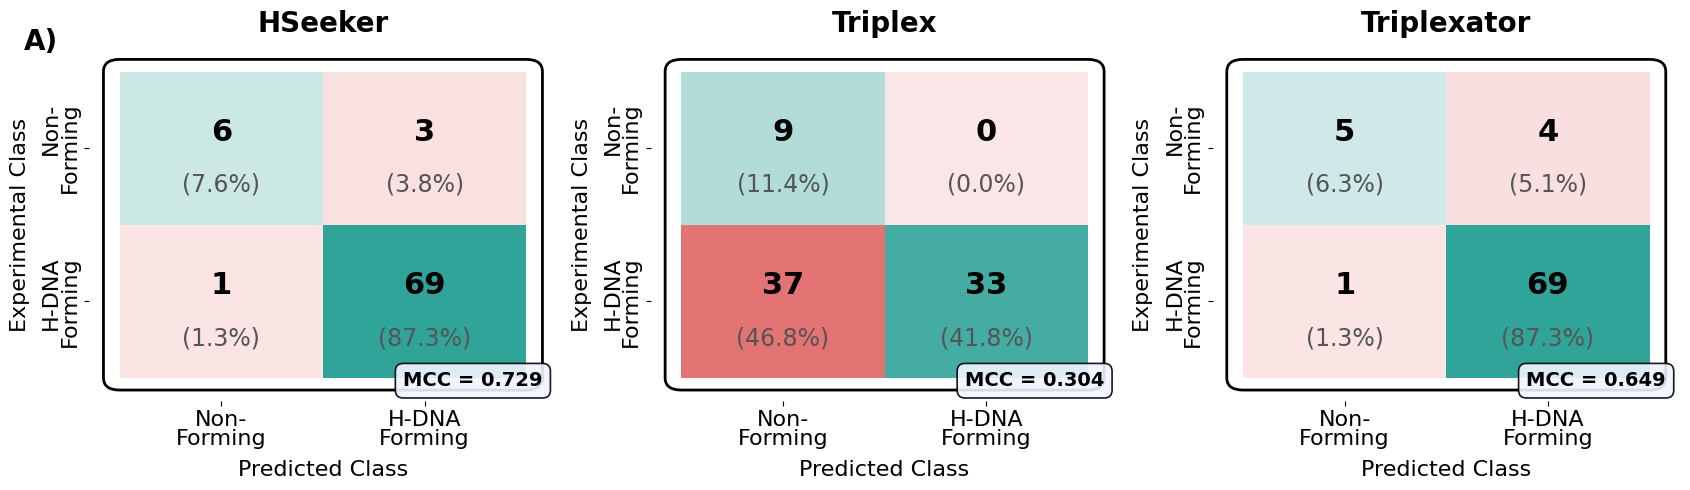

Injected — HSeeker MCC=0.729  R triplex MCC=0.304  Triplexator MCC=0.649


In [ ]:
uids   = [ins["uid"]   for ins in insertions]
labels = [ins["label"] for ins in insertions]

y_true_inj   = pd.Series(labels).eq("forming").astype(int).values
y_pred_hs_i  = (results_df.set_index("uid")["hseeker_hit"]
               .reindex(uids).fillna(False).astype(int).values)
y_pred_tri_i = (triplex_full_results.set_index("uid")["triplex_full_hit"]
               .reindex(uids).fillna(False).astype(int).values)
y_pred_trtor_i = (triplexator_inj_results.set_index("uid")["triplexator_inj_hit"]
                 .reindex(uids).fillna(False).astype(int).values)

cm_hs_i     = confusion_matrix(y_true_inj, y_pred_hs_i)
cm_tri_i    = confusion_matrix(y_true_inj, y_pred_tri_i)
cm_trtor_i  = confusion_matrix(y_true_inj, y_pred_trtor_i)
mcc_hs_i    = matthews_corrcoef(y_true_inj, y_pred_hs_i)
mcc_tri_i   = matthews_corrcoef(y_true_inj, y_pred_tri_i)
mcc_trtor_i = matthews_corrcoef(y_true_inj, y_pred_trtor_i)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), facecolor=WHITE)
draw_cm(axes[0], cm_hs_i,    "HSeeker",             mcc_hs_i,   "A")
draw_cm(axes[1], cm_tri_i,   "Triplex", mcc_tri_i,  "")
draw_cm(axes[2], cm_trtor_i, "Triplexator",         mcc_trtor_i,"")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cm_injected_3way.pdf", bbox_inches="tight", facecolor=WHITE)
plt.show()
print(f"Injected — HSeeker MCC={mcc_hs_i:.3f}  R triplex MCC={mcc_tri_i:.3f}  Triplexator MCC={mcc_trtor_i:.3f}")

## 9. Sensitivity & Specificity Summary

In [ ]:
def classification_summary(y_true, y_pred, name):
    TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()
    sens = TP / (TP + FN) if (TP + FN) else 0
    spec = TN / (TN + FP) if (TN + FP) else 0
    prec = TP / (TP + FP) if (TP + FP) else 0
    f1   = 2 * prec * sens / (prec + sens) if (prec + sens) else 0
    mcc  = matthews_corrcoef(y_true, y_pred)
    return {"Method": name, "TP": TP, "FN": FN, "TN": TN, "FP": FP,
            "Sensitivity %": round(sens * 100, 1),
            "Specificity %": round(spec * 100, 1),
            "Precision %":   round(prec * 100, 1),
            "F1":  round(f1,  3),
            "MCC": round(mcc, 3)}

rows = [
    classification_summary(y_true_dir,  y_pred_hs,       "HSeeker — direct"),
    classification_summary(y_true_dir,  y_pred_tri,      "R triplex — direct"),
    classification_summary(y_true_dir,  y_pred_trtor_d,  "Triplexator — direct"),
    classification_summary(y_true_inj,  y_pred_hs_i,     "HSeeker — injected"),
    classification_summary(y_true_inj,  y_pred_tri_i,    "R triplex — injected (chunked)"),
    classification_summary(y_true_inj,  y_pred_trtor_i,  "Triplexator — injected"),
]

summary_df = pd.DataFrame(rows).set_index("Method")
print(summary_df.to_string())

                                TP  FN  TN  FP  Sensitivity %  Specificity %  Precision %     F1    MCC
Method                                                                                                 
HSeeker — direct                69   1   6   3           98.6           66.7         95.8  0.972  0.729
R triplex — direct              67   3   7   2           95.7           77.8         97.1  0.964  0.702
Triplexator — direct            69   1   5   4           98.6           55.6         94.5  0.965  0.649
HSeeker — injected              69   1   6   3           98.6           66.7         95.8  0.972  0.729
R triplex — injected (chunked)  33  37   9   0           47.1          100.0        100.0  0.641  0.304
Triplexator — injected          69   1   5   4           98.6           55.6         94.5  0.965  0.649


## 10. Stability score distribution by label

/tmp/ipykernel_256413/962161134.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=detected_df, x="label", y="stab_score",
/tmp/ipykernel_256413/962161134.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=detected_df, x="label", y="stab_score",


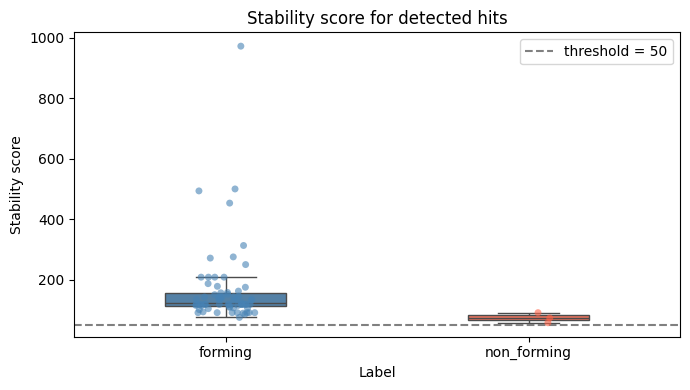

In [ ]:
detected_df = results_df.dropna(subset=["stab_score"])

STAB_THRESHOLD = 50
fig, ax = plt.subplots(figsize=(7, 4))
sns.stripplot(data=detected_df, x="label", y="stab_score",
              order=["forming", "non_forming"],
              palette={"forming": "steelblue", "non_forming": "tomato"},
              alpha=0.6, jitter=True, ax=ax)
sns.boxplot(data=detected_df, x="label", y="stab_score",
            order=["forming", "non_forming"],
            palette={"forming": "steelblue", "non_forming": "tomato"},
            width=0.4, fliersize=0, ax=ax)
ax.axhline(STAB_THRESHOLD, ls="--", color="grey", label=f"threshold = {STAB_THRESHOLD}")
ax.set_xlabel("Label")
ax.set_ylabel("Stability score")
ax.set_title("Stability score for detected hits")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stability_dist.png", dpi=150)
plt.show()

## 11. Per-sequence summary

In [ ]:
summary = (
    results_df.groupby(["record_id", "sequence_name", "label"])
    .agg(
        replicates=("uid", "count"),
        hseeker_detected=("hseeker_hit", "sum"),
        mean_stab=("stab_score", "mean"),
    )
    .reset_index()
)
summary["detection_rate"] = summary["hseeker_detected"] / summary["replicates"]
summary.sort_values(["label", "detection_rate"], ascending=[True, False])

,record_id,sequence_name,label,replicates,hseeker_detected,mean_stab,detection_rate
0,AA32,AA32,forming,1,1,136.18,1.0
1,AG11_model,AG11_model,forming,1,1,102.15,1.0
2,BCL6_ClusterII_Pu,BCL6_ClusterII_Pu,forming,1,1,134.89,1.0
3,CANVAS_AAGGG10,CANVAS_AAGGG10,forming,1,1,272.30,1.0
4,CTC16_mouse,CTC16_mouse,forming,1,1,145.01,1.0
...,...,...,...,...,...,...,...
35,HDNA0021,ΔCT/Ri,non_forming,1,0,NaN,0.0
43,HDNA0029,"pCON (S1, pH 4.5)",non_forming,1,0,NaN,0.0
45,HDNA0031,"pMycAG (S1, pH 4.5)",non_forming,1,0,NaN,0.0
50,HDNA0036,Mycm1,non_forming,1,0,NaN,0.0


## 12. PIT Element Detection
Assess the 25 PIT elements directly with HSeeker, R triplex, and Triplexator.

In [ ]:
PIT_DIRECT_FASTA = "pit_direct_sequences.fasta"
PIT_DIRECT_OUT = "pit_direct"
PIT_DIRECT_TSV = f"{PIT_DIRECT_OUT}_HDNA.tsv"

with open(PIT_DIRECT_FASTA, "w") as f:
    for _, row in pit_df.iterrows():
        f.write(f">{row['record_id']}\n{row['sequence_5to3']}\n")

cmd = (
    f"hseeker -seq {PIT_DIRECT_FASTA} "
    f"-minrep 8 -maxspacer 10 -mismatch 0.3 -maxrep 1000 -purity 0.8 "
    f"-out {PIT_DIRECT_OUT}"
)
print("Running:", cmd)
result = run(cmd, shell=True, capture_output=True, text=True)
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])

df_pit_hits = pd.read_table(PIT_DIRECT_TSV)
print(f"\n{len(df_pit_hits)} HSeeker hits")

pit_direct_hits = set(df_pit_hits["seq_id"].unique())
pit_direct_df = pit_df.copy()
pit_direct_df["hseeker_direct_hit"] = pit_direct_df["record_id"].isin(pit_direct_hits)
print(pit_direct_df[["record_id", "sequence_5to3", "hseeker_direct_hit"]].to_string(index=False))

Running: hseeker -seq pit_direct_sequences.fasta -minrep 8 -maxspacer 10 -mismatch 0.3 -maxrep 1000 -purity 0.8 -out pit_direct

24 HSeeker hits
record_id           sequence_5to3  hseeker_direct_hit
    PIT01 AGGGAGAGGGCCGGGGTGAGGGT                True
    PIT02 GGGGAGAGGGTTAGGGTGAGGGG                True
    PIT03   GGGAGAGGGCCGGGGTGAGGG                True
    PIT04 AGGGAGAGGGTTAGGGTGAGGGT                True
    PIT05       AGGGAGAGGGTTAGGGT               False
    PIT06 GGGGAGAGGGCCGGGGTGAGGGG                True
    PIT07 AGGGAGAGGGTCGGGGTGAGGGT                True
    PIT08 GGGGAGAGGGTTAGGGTGAGGGG                True
    PIT09 GGGGAGAGGGTTAGGGTGAGGGG                True
    PIT10 AGGGTGAGGGCTGGGGTGAGGGT                True
    PIT11 GGGGAGAGGGTTAGGGTGAGGGG                True
    PIT12 GGGGAGAGGATTAGGGTGAGGGG                True
    PIT13 GGGGAGAGGGTTAGGGTGAGGGG                True
    PIT14   GGAGAGGGTTTGGGTGAGGGA                True
    PIT15 GGGGAGAGGGTTAGGGTGAGGGG            

### 12b. PIT Elements — R triplex & Triplexator

In [ ]:
PIT_TRIPLEX_INPUT = "pit_direct_input.tsv"
PIT_TRIPLEX_TSV = "triplex_pit_direct.tsv"

pit_df[["record_id", "sequence_5to3"]].rename(
    columns={"sequence_5to3": "sequence"}
).to_csv(PIT_TRIPLEX_INPUT, sep="\t", index=False)

print("Running triplex on PIT direct sequences...")
result = run(
    ["Rscript", TRIPLEX_SCRIPT,
     PIT_TRIPLEX_INPUT, PIT_TRIPLEX_TSV,
     str(TRIPLEX_MIN_SCORE), str(TRIPLEX_MIN_LEN), str(TRIPLEX_MAX_LEN),
     TRIPLEX_SEQ_TYPE],
    capture_output=True, text=True,
)
print(result.stdout.strip() or "(no stdout)")
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])

triplex_pit_direct_df = pd.read_table(PIT_TRIPLEX_TSV, na_values=["NA"])
triplex_pit_direct_hits = set(triplex_pit_direct_df.dropna(subset=["start"])["record_id"].unique())
pit_direct_df["triplex_direct_hit"] = pit_direct_df["record_id"].isin(triplex_pit_direct_hits)
print(pit_direct_df[["record_id", "sequence_5to3", "triplex_direct_hit"]].to_string(index=False))

Running triplex on PIT direct sequences...


Searching for triplex type 0...
Searching for triplex type 1...
Searching for triplex type 2...
Searching for triplex type 3...
Searching for triplex type 4...
Searching for triplex type 5...
Searching for triplex type 6...
Searching for triplex type 7...
  [1/25] PIT01
Searching for triplex type 0...
Searching for triplex type 1...
Searching for triplex type 2...
Searching for triplex type 3...
Searching for triplex type 4...
Searching for triplex type 5...
Searching for triplex type 6...
Searching for triplex type 7...
  [2/25] PIT02
Searching for triplex type 0...
Searching for triplex type 1...
Searching for triplex type 2...
Searching for triplex type 3...
Searching for triplex type 4...
Searching for triplex type 5...
Searching for triplex type 6...
Searching for triplex type 7...
  [3/25] PIT03
Searching for triplex type 0...
Searching for triplex type 1...
Searching for triplex type 2...
Searching for triplex type 3...
Searching for triplex type 4...
Searching for triplex type 

In [87]:
PIT_TRIPLEXATOR_OUT = "triplexator_pit_direct_out"

cmd = [
    TRIPLEXATOR_BIN,
    "-ds", PIT_DIRECT_FASTA,
    "-l", str(TRIPLEXATOR_MIN_LEN),
    "-L", str(TRIPLEXATOR_MAX_LEN),
    "-e", str(TRIPLEXATOR_ERROR),
    "-fr", "off",
    "-o", PIT_TRIPLEXATOR_OUT,
]
print("Running Triplexator on PIT direct sequences...")
result = run(cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])

tri_ttor_pit_direct_raw = pd.read_table(
    PIT_TRIPLEXATOR_OUT,
    comment="#", header=None,
    names=["seq_id","start","end","score","strand","error_rate","errors","g_rate","dups","tts","dup_locs"],
    sep="\t",
)
print(f"Total Triplexator hits: {len(tri_ttor_pit_direct_raw)}")

triplexator_pit_direct_hits = set(tri_ttor_pit_direct_raw["seq_id"].unique())
pit_direct_df["triplexator_direct_hit"] = pit_direct_df["record_id"].isin(triplexator_pit_direct_hits)
print(pit_direct_df[["record_id", "sequence_5to3", "triplexator_direct_hit"]].to_string(index=False))

Running Triplexator on PIT direct sequences...
Total Triplexator hits: 46
record_id           sequence_5to3  triplexator_direct_hit
    PIT01 AGGGAGAGGGCCGGGGTGAGGGT                    True
    PIT02 GGGGAGAGGGTTAGGGTGAGGGG                    True
    PIT03   GGGAGAGGGCCGGGGTGAGGG                    True
    PIT04 AGGGAGAGGGTTAGGGTGAGGGT                    True
    PIT05       AGGGAGAGGGTTAGGGT                    True
    PIT06 GGGGAGAGGGCCGGGGTGAGGGG                    True
    PIT07 AGGGAGAGGGTCGGGGTGAGGGT                    True
    PIT08 GGGGAGAGGGTTAGGGTGAGGGG                    True
    PIT09 GGGGAGAGGGTTAGGGTGAGGGG                    True
    PIT10 AGGGTGAGGGCTGGGGTGAGGGT                    True
    PIT11 GGGGAGAGGGTTAGGGTGAGGGG                    True
    PIT12 GGGGAGAGGATTAGGGTGAGGGG                    True
    PIT13 GGGGAGAGGGTTAGGGTGAGGGG                    True
    PIT14   GGAGAGGGTTTGGGTGAGGGA                    True
    PIT15 GGGGAGAGGGTTAGGGTGAGGGG                    Tru

In [88]:
# 3-way per-element summary for PIT elements
pit_3way = pit_direct_df[["record_id", "sequence_5to3", "hseeker_direct_hit", "triplex_direct_hit", "triplexator_direct_hit"]].copy()
pit_3way = pit_3way.rename(columns={"sequence_5to3": "sequence"})

pit_3way["HSeeker"] = pit_3way["hseeker_direct_hit"].map({True: "detected", False: "not detected"})
pit_3way["R triplex"] = pit_3way["triplex_direct_hit"].map({True: "detected", False: "not detected"})
pit_3way["Triplexator"] = pit_3way["triplexator_direct_hit"].map({True: "detected", False: "not detected"})

print("PIT element detection — direct 3-way comparison")
print(pit_3way[["record_id", "sequence", "HSeeker", "R triplex", "Triplexator"]].to_string(index=False))

print("\n=== Missed by at least one tool ===")
missed_mask = (
    (~pit_3way["hseeker_direct_hit"]) |
    (~pit_3way["triplex_direct_hit"]) |
    (~pit_3way["triplexator_direct_hit"])
)
print(pit_3way.loc[missed_mask, ["record_id", "sequence", "HSeeker", "R triplex", "Triplexator"]].to_string(index=False))

PIT element detection — direct 3-way comparison
record_id                sequence      HSeeker    R triplex Triplexator
    PIT01 AGGGAGAGGGCCGGGGTGAGGGT     detected not detected    detected
    PIT02 GGGGAGAGGGTTAGGGTGAGGGG     detected     detected    detected
    PIT03   GGGAGAGGGCCGGGGTGAGGG     detected not detected    detected
    PIT04 AGGGAGAGGGTTAGGGTGAGGGT     detected not detected    detected
    PIT05       AGGGAGAGGGTTAGGGT not detected not detected    detected
    PIT06 GGGGAGAGGGCCGGGGTGAGGGG     detected     detected    detected
    PIT07 AGGGAGAGGGTCGGGGTGAGGGT     detected not detected    detected
    PIT08 GGGGAGAGGGTTAGGGTGAGGGG     detected     detected    detected
    PIT09 GGGGAGAGGGTTAGGGTGAGGGG     detected     detected    detected
    PIT10 AGGGTGAGGGCTGGGGTGAGGGT     detected not detected    detected
    PIT11 GGGGAGAGGGTTAGGGTGAGGGG     detected     detected    detected
    PIT12 GGGGAGAGGATTAGGGTGAGGGG     detected not detected    detected
    PIT13 GGGGAG

In [74]:
# Sanity check on a non-injected PIT control sequence
pit_control = pit_df.iloc[0]

pit_control_summary = pd.DataFrame([
    {
        "record_id": pit_control["record_id"],
        "sequence": pit_control["sequence_5to3"],
        "status": "not injected into the benchmark genome",
        "HSeeker": "not injected",
        "R triplex": "not injected",
        "Triplexator": "not injected",
    }
])

print("Non-injected PIT control sequence check")
print(pit_control_summary.to_string(index=False))

Non-injected PIT control sequence check
record_id                sequence                                 status      HSeeker    R triplex  Triplexator
    PIT01 AGGGAGAGGGCCGGGGTGAGGGT not injected into the benchmark genome not injected not injected not injected


In [61]:
# Print each benchmark sequence with ±15 bp flanking as FASTA
FLANK = 15

_, bench_genome = read_single_fasta(OUT_FNA)
bench_genome = bench_genome.upper()

with open(OUT_JSON) as f:
    bench_insertions = json.load(f)

print(f"# Benchmark sequences embedded in E. coli K-12 with ±{FLANK} bp flanking")
print(f"# lowercase = flanking genomic sequence, UPPERCASE = inserted sequence\n")

seen = set()
for ins in sorted(bench_insertions, key=lambda x: x['record_id']):
    rid = ins['record_id']
    if rid in seen:
        continue
    seen.add(rid)

    pos   = ins['position']
    seq   = ins['sequence']
    name  = ins['sequence_name']
    label = ins['label']
    start = max(0, pos - FLANK)
    end   = min(len(bench_genome), pos + len(seq) + FLANK)

    left_flank  = bench_genome[start:pos]
    insert      = bench_genome[pos:pos+len(seq)]
    right_flank = bench_genome[pos+len(seq):end]

    header = (f">{rid} | {name} | {label} | "
              f"genome_pos={pos}-{pos+len(seq)-1} | len={len(seq)}")

    print(header)
    print(f"{left_flank.lower()}{insert}{right_flank.lower()}")
    print()


# Benchmark sequences embedded in E. coli K-12 with ±15 bp flanking
# lowercase = flanking genomic sequence, UPPERCASE = inserted sequence

>AA32 | AA32 | forming | genome_pos=3191749-3191778 | len=30
aaagcgtcactacgcAAGGGAGAAAGGGTATAGGGAAAGAGGGAAgccagttatcagcat

>AG11_model | AG11_model | forming | genome_pos=1372181-1372202 | len=22
gtttaacttcctcgcAGAGAGAGAGAGAGAGAGAGAGctctcacgatggcat

>BCL6_ClusterII_Pu | BCL6_ClusterII_Pu | forming | genome_pos=3063232-3063255 | len=24
cgctggttcatcaaaGGGAGGAGGGAGGAGGGAGGAGGGccgcggaagggatcg

>CANVAS_AAGGG10 | CANVAS_AAGGG10 | forming | genome_pos=2241803-2241852 | len=50
acccgcagctgccggAAGGGAAGGGAAGGGAAGGGAAGGGAAGGGAAGGGAAGGGAAGGGAAGGGgtcaaccaggttgat

>CTC16_mouse | CTC16_mouse | forming | genome_pos=4484109-4484141 | len=33
catcttctttgttgaCTCTCTCTCTCTCTCTCTCTCTCTCTCTCTCTCtgaggccagccatcg

>CTC20_mouse | CTC20_mouse | forming | genome_pos=1437099-1437139 | len=41
tcatattacgcgtttCTCTCTCTCTCTCTCTCTCTCTCTCTCTCTCTCTCTCTCTCctgaatacatggttg

>FXN_GAA10 | FXN

In [62]:
# Print PIT elements with ±15 bp flanking as FASTA
FLANK = 15

_, pit_genome = read_single_fasta(PIT_FNA)
pit_genome = pit_genome.upper()

# arm_length lookup from pit_df
al_lookup = dict(zip(pit_df['record_id'], pit_df['arm_length']))

print(f"# PIT elements embedded in E. coli K-12 with ±{FLANK} bp flanking")
print(f"# lowercase = flanking genomic sequence, UPPERCASE = inserted sequence\n")

seen = set()
for ins in sorted(pit_insertions, key=lambda x: x['record_id']):
    rid = ins['record_id']
    if rid in seen:
        continue
    seen.add(rid)

    pos   = ins['position']
    seq   = ins['sequence']
    al    = al_lookup[rid]
    start = max(0, pos - FLANK)
    end   = min(len(pit_genome), pos + len(seq) + FLANK)

    left_flank  = pit_genome[start:pos]
    insert      = pit_genome[pos:pos+len(seq)]
    right_flank = pit_genome[pos+len(seq):end]

    la = insert[:al]
    sp = insert[al:len(insert)-al]
    ra = insert[len(insert)-al:]

    header = (f">{rid} | {la}[{sp}]{ra} | "
              f"genome_pos={pos}-{pos+len(seq)-1} | len={len(seq)}")

    print(header)
    print(f"{left_flank.lower()}{insert}{right_flank.lower()}")
    print()


# PIT elements embedded in E. coli K-12 with ±15 bp flanking
# lowercase = flanking genomic sequence, UPPERCASE = inserted sequence

>PIT01 | AGGGAGAGGG[CCG]GGGTGAGGGT | genome_pos=94066-94088 | len=23
tatcacgacagcggtAGGGAGAGGGCCGGGGTGAGGGTgcgacgattcgcttt

>PIT02 | GGGGAGAGGG[TTA]GGGTGAGGGG | genome_pos=311492-311514 | len=23
accggaagtaaataaGGGGAGAGGGTTAGGGTGAGGGGgatacgtagtacata

>PIT03 | GGGAGAGGG[CCG]GGGTGAGGG | genome_pos=922009-922029 | len=21
tgaccttcagtgaagGGGAGAGGGCCGGGGTGAGGGgaaacacctttaatc

>PIT04 | AGGGAGAGGG[TTA]GGGTGAGGGT | genome_pos=196055-196077 | len=23
cgctattgctggtgcAGGGAGAGGGTTAGGGTGAGGGTtgttttacccaggtt

>PIT05 | AGGGAGAG[G]GTTAGGGT | genome_pos=1099434-1099450 | len=17
ggggagagggtctgcAGGGAGAGGGTTAGGGTgggcaagtcgaccgc

>PIT06 | GGGGAGAGGG[CCG]GGGTGAGGGG | genome_pos=358424-358446 | len=23
tcgtcgcggcaaagcGGGGAGAGGGCCGGGGTGAGGGGatatcctcgattttc

>PIT07 | AGGGAGAGG[GTCGG]GGTGAGGGT | genome_pos=1118892-1118914 | len=23
cggcgtgattagtatAGGGAGAGGGTCGGGGTGAGGGTcgacgctggtggtgt
